## Импорты и настройки


In [106]:
import pandas as pd
import numpy as np
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [107]:
# Подключение Google диска
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [108]:
# Настройка выводов
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [109]:
info_dict = {
    "ID": "Номер записи",
    "shop_id": "Порядковый номер магазина",
    "item_id": "Порядковый номер товара",
    "item_category_id": "Порядковый номер категории",
    "item_cnt_day": "Продано за день",
    "item_price": "Цена товрара",
    "date": "Дата продажи dd/mm/yyyy",
    "date_block_num": "Порядковый номер месяца, используемый для удобства",
    "item_name": "Название товара",
    "shop_name": "Название магазина",
    "item_category_name": "Название категории товара",
}

In [110]:
def descr_features(data):
    # Отфильтруем столбцы, исключив те, что содержат 'id' в названии
    cols = [col for col in data.columns if 'id' not in col.lower()]
    data = data[cols]

    # Тип данных
    features = data.dtypes.to_frame(name="data_type")

    # Текстовое описание (предполагаем, что info_dict объявлен вне функции)
    features["meaning"] = [info_dict.get(x, "new") for x in features.index]

    # Кол-во и % пропусков
    features["n_NaN"] = data.isna().sum()
    features["%NaN"] = round(features["n_NaN"] / len(data) * 100, 2)

    # Количество уникальных значений
    features["nunique"] = data.nunique().values

    # Статистики describe()
    describe_train = data.describe(include="all").round(1).T
    features = pd.merge(
        features,
        describe_train.round(0),
        how="left",
        left_index=True,
        right_index=True
    )

    return features

## Загрузка данных

In [111]:
train = pd.read_csv("/content/drive/MyDrive/DS/data/sales_train.csv")
train.head(10)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0
5,10.01.2013,0,25,2564,349.00,1.0
6,02.01.2013,0,25,2565,549.00,1.0
7,04.01.2013,0,25,2572,239.00,1.0
8,11.01.2013,0,25,2572,299.00,1.0
9,03.01.2013,0,25,2573,299.00,3.0


In [112]:
# Парсинг дат
train['date'] = pd.to_datetime(train['date'], errors='coerce', format='%d.%m.%Y')

train["day"] = train["date"].apply(lambda x: x.day)
train["month"] = train["date"].apply(lambda x: x.month)
train["year"] = train["date"].apply(lambda x: x.year)

# Удаляем date_time признак
train = train.drop(columns=["date"])

In [113]:
test = pd.read_csv("/content/drive/MyDrive/DS/data/test.csv")
test.drop(columns=["ID"], inplace=True)
test.head()

,shop_id,item_id
0,5,5037
1,5,5320
2,5,5233
3,5,5232
4,5,5268


In [114]:
items = pd.read_csv("/content/drive/MyDrive/DS/data/items.csv")
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [115]:
train.head()

,date_block_num,shop_id,item_id,item_price,item_cnt_day,day,month,year
0,0,59,22154,999.00,1.0,2,1,2013
1,0,25,2552,899.00,1.0,3,1,2013
2,0,25,2552,899.00,-1.0,5,1,2013
3,0,25,2554,1709.05,1.0,6,1,2013
4,0,25,2555,1099.00,1.0,15,1,2013


## Предварительная обработка данных

In [116]:
descr_features(train)

,data_type,meaning,n_NaN,%NaN,nunique,count,mean,std,min,25%,50%,75%,max
date_block_num,int64,"Порядковый номер месяца, используемый для удоб...",0,0.0,34,2935849.0,15.0,9.0,0.0,7.0,14.0,23.0,33.0
item_price,float64,Цена товрара,0,0.0,19993,2935849.0,891.0,1730.0,-1.0,249.0,399.0,999.0,307980.0
item_cnt_day,float64,Продано за день,0,0.0,198,2935849.0,1.0,3.0,-22.0,1.0,1.0,1.0,2169.0
day,int64,new,0,0.0,31,2935849.0,16.0,9.0,1.0,8.0,16.0,24.0,31.0
month,int64,new,0,0.0,12,2935849.0,6.0,4.0,1.0,3.0,6.0,9.0,12.0
year,int64,new,0,0.0,3,2935849.0,2014.0,1.0,2013.0,2013.0,2014.0,2014.0,2015.0


In [117]:
# Удаление дубликатов
train.drop_duplicates(inplace=True)
print(f"Количество дубликатов: {train.duplicated().sum()}")
print(f"Процент дубликатов: {train.duplicated().sum()/train.shape[0]}\n")

Количество дубликатов: 0
Процент дубликатов: 0.0



In [118]:
# Удаление строки с отрицательной ценой товара
train.drop(train[train["item_price"]==-1].index, inplace=True)

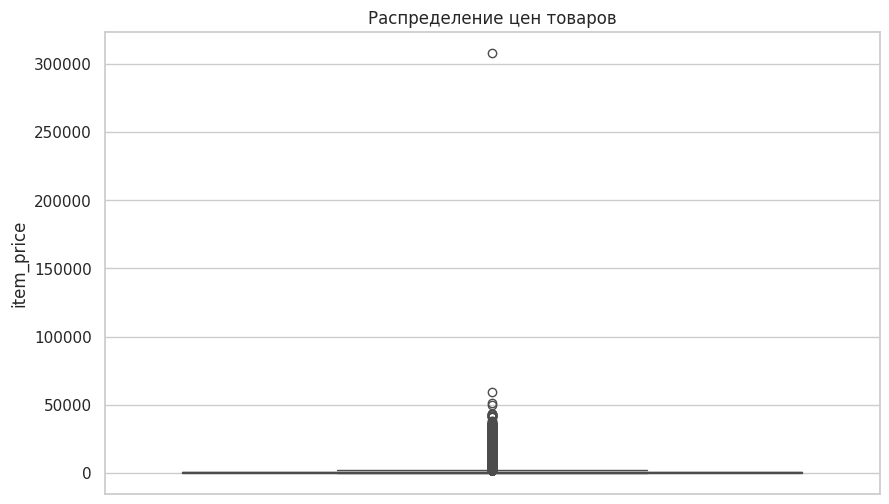

In [119]:
plt.figure(figsize=(10, 6))
sns.boxplot(train['item_price'])
plt.title('Распределение цен товаров')
plt.show()

In [120]:
# Удаление аномалии в цене
train.drop(train[train["item_price"]>200000].index, inplace=True)

In [121]:
# Приведение типов к int32
int_columns = train.columns.drop("item_price")
train[int_columns] = train[int_columns].astype("int32")
print(train[int_columns].dtypes)

date_block_num    int32
shop_id           int32
item_id           int32
item_cnt_day      int32
day               int32
month             int32
year              int32
dtype: object


In [122]:
# Словарь переименования shop_id
shop_id_map = {
    0: 57,   # Якутск Орджоникидзе, 56
    1: 58,   # Якутск ТЦ "Центральный"
    10: 11   # Жуковский ул. Чкалова 39м²
}

# Замена shop_id в train и test
train['shop_id'] = train['shop_id'].replace(shop_id_map)
test['shop_id'] = test['shop_id'].replace(shop_id_map)

In [123]:
descr_features(train)

,data_type,meaning,n_NaN,%NaN,nunique,count,mean,std,min,25%,50%,75%,max
date_block_num,int32,"Порядковый номер месяца, используемый для удоб...",0,0.0,34,2935841.0,15.0,9.0,0.0,7.0,14.0,23.0,33.0
item_price,float64,Цена товрара,0,0.0,19991,2935841.0,891.0,1720.0,0.0,249.0,399.0,999.0,59200.0
item_cnt_day,int32,Продано за день,0,0.0,198,2935841.0,1.0,3.0,-22.0,1.0,1.0,1.0,2169.0
day,int32,new,0,0.0,31,2935841.0,16.0,9.0,1.0,8.0,16.0,24.0,31.0
month,int32,new,0,0.0,12,2935841.0,6.0,4.0,1.0,3.0,6.0,9.0,12.0
year,int32,new,0,0.0,3,2935841.0,2014.0,1.0,2013.0,2013.0,2014.0,2014.0,2015.0


## Визуальный анализ

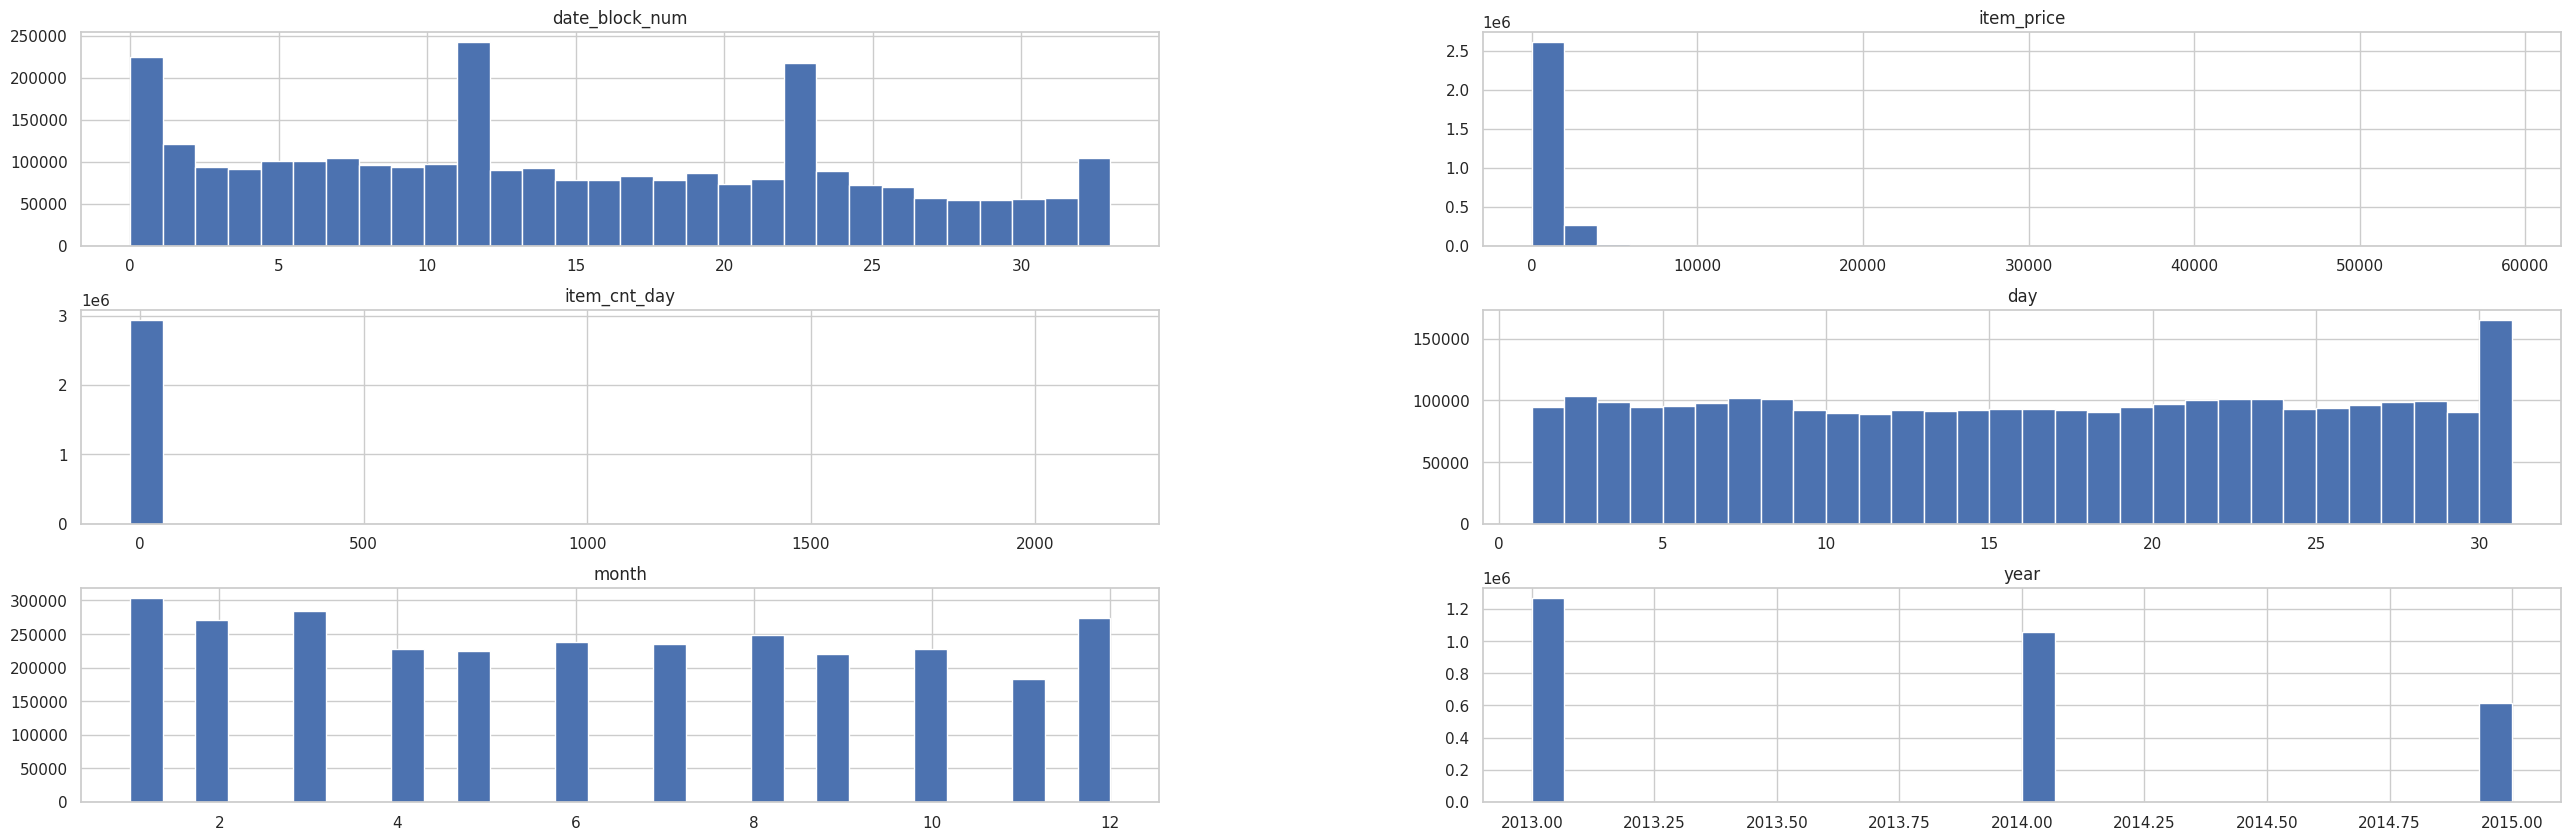

In [124]:
# Распределение признаков
train.drop(columns=["item_id", "shop_id"]).hist(bins=30, figsize=(32, 10), sharex=False);

- На графике количества сразу видно, что обычно клиенты покупают 1 шт нужного товара.
- Длинный хвост вправо у распределения цены, то есть товары с высокой ценой, но они встречаются редко.


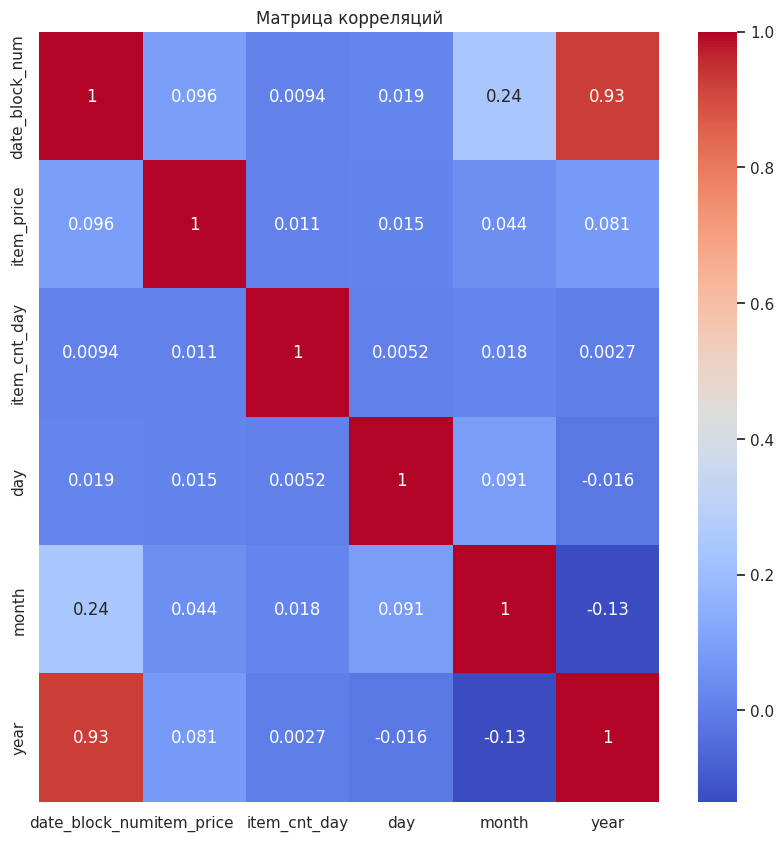

In [125]:
# Построение матрицы корреляций
plt.figure(figsize=(10, 10))
plt.title("Матрица корреляций")
sns.heatmap(train.drop(columns=["shop_id", "item_id"]).corr(), annot=True, cmap='coolwarm');

Признаки слабо коррелируют друг с другом. Признак date_block_num по сути дублирует year и month.

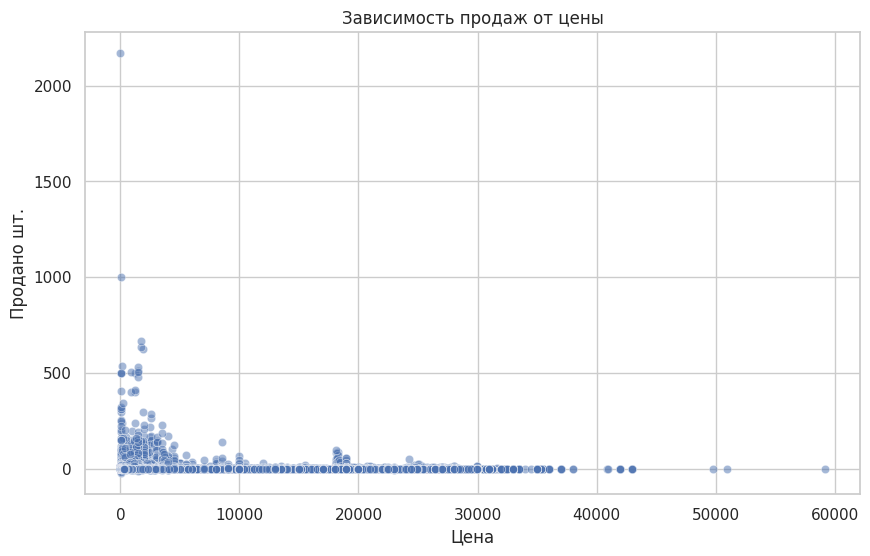

In [126]:
# Точечный график кличества проданных товаров от цены
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='item_price', y='item_cnt_day', alpha=0.5)
plt.title('Зависимость продаж от цены')
plt.xlabel('Цена')
plt.ylabel('Продано шт.')
plt.grid(True)
plt.show()

 Наблюдаемый спад продаж при увеличении цены подтверждает чувствительность потребителей к стоимости продукции.

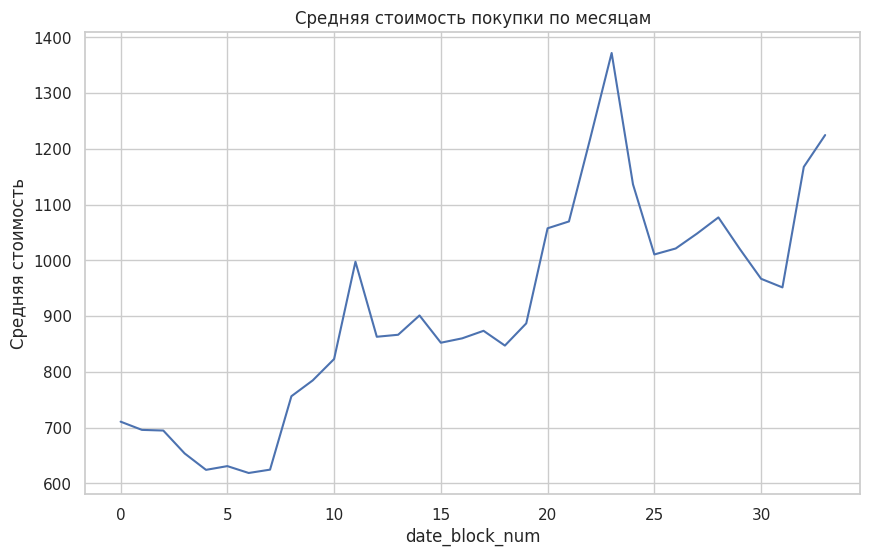

In [127]:
# Средний чек
monthly_price = train.groupby('date_block_num')['item_price'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_price, x='date_block_num', y='item_price')
plt.title('Средняя стоимость покупки по месяцам')
plt.xlabel('date_block_num')
plt.ylabel('Средняя стоимость')
plt.grid(True)
plt.show()

За 3 года средний чек увеличился с 700 у е до 1230 у е. С учётом инфляции этот рост составляет примерно 60 %.

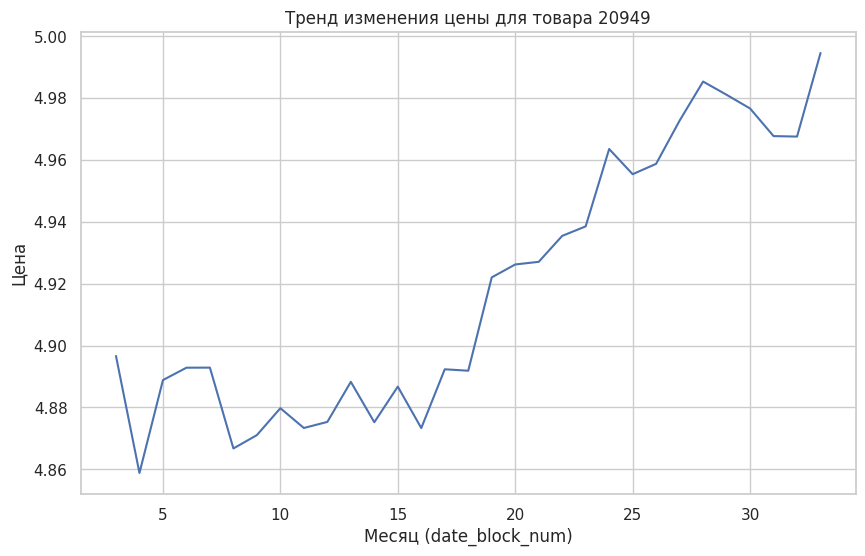

In [128]:
# Тренд изменения цены по 1 из товаров
item_id_example = train['item_id'].value_counts().index[0]  # самый популярный товар
item_price_trend = train[train['item_id'] == item_id_example].groupby('date_block_num')['item_price'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=item_price_trend, x='date_block_num', y='item_price')
plt.title(f'Тренд изменения цены для товара {item_id_example}')
plt.xlabel('Месяц (date_block_num)')
plt.ylabel('Цена')
plt.grid(True)
plt.show()

Цена популярного товара выросла за три года на 0.14 (3 %)

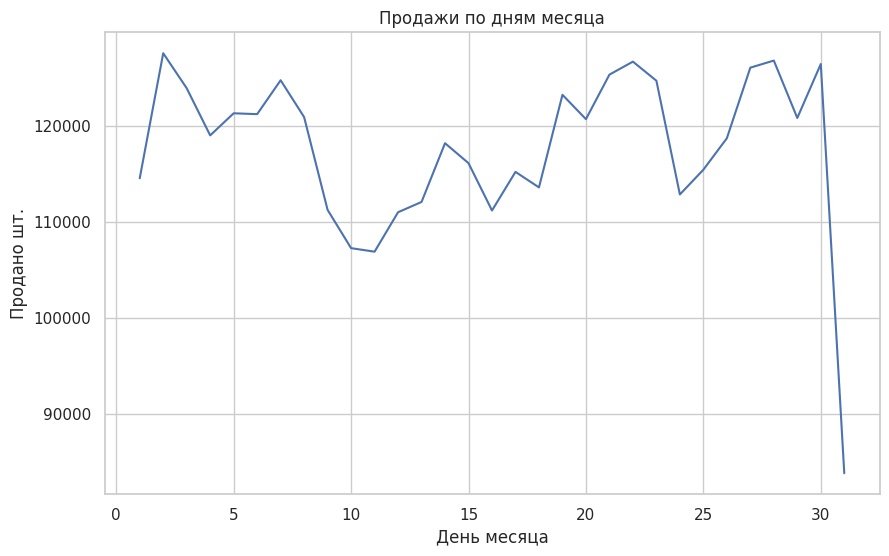

In [129]:
# Продажи по дням месяца
day_sales = train.groupby('day')['item_cnt_day'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=day_sales, x='day', y='item_cnt_day')
plt.title('Продажи по дням месяца')
plt.xlabel('День месяца')
plt.ylabel('Продано шт.')
plt.grid(True)
plt.show()

Продажи падают к 10 дню месяца и к 24. (31 день есть не в каждом). Люди получают зп чаще в начале или середине месяца.
- К 10 числу: первая волна трат заканчивается, люди начинают экономить, особенно если зарплата была потрачена на обязательные платежи (аренда, кредиты, коммуналка).
- К 24 числу (конец 2 влоны трат): деньги заканчиваются, начинается режим ожидания следующей зарплаты. Продажи падают.

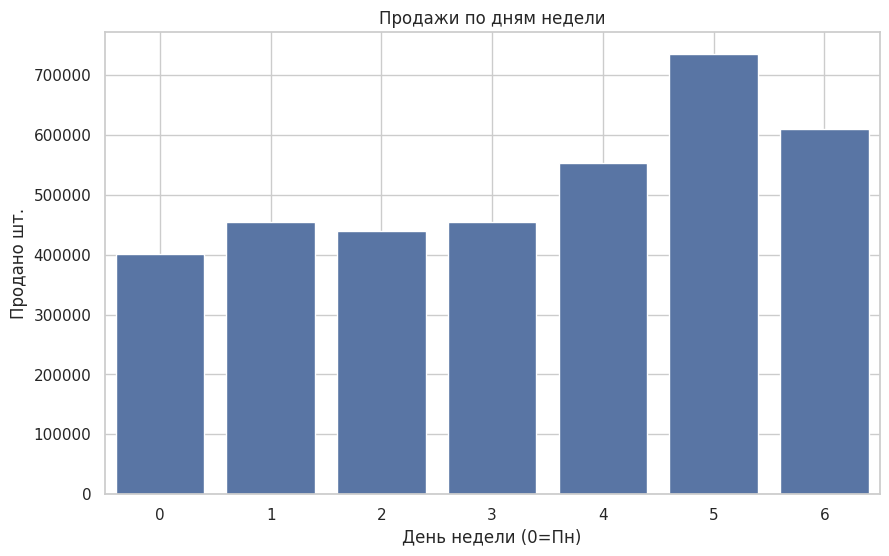

In [130]:
# Продажи по дням недели
train['weekday'] = pd.to_datetime(train[['year', 'month', 'day']]).dt.dayofweek  # 0=Пн, 6=Вс

weekday_sales = train.groupby('weekday')['item_cnt_day'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=weekday_sales, x='weekday', y='item_cnt_day')
plt.title('Продажи по дням недели')
plt.xlabel('День недели (0=Пн)')
plt.ylabel('Продано шт.')
plt.grid(True)
plt.show()

В субботу наблюдается пик продаж

## Аггрегация и дополнение

In [131]:
# Аггрегация
train_grouped = train.groupby(['date_block_num', 'shop_id', 'item_id'], as_index=False).agg({
    'item_cnt_day':'sum' # получаем количество проданного товара за месяц
})
train_grouped.rename(columns={'item_cnt_day':'item_cnt_month'}, inplace=True)

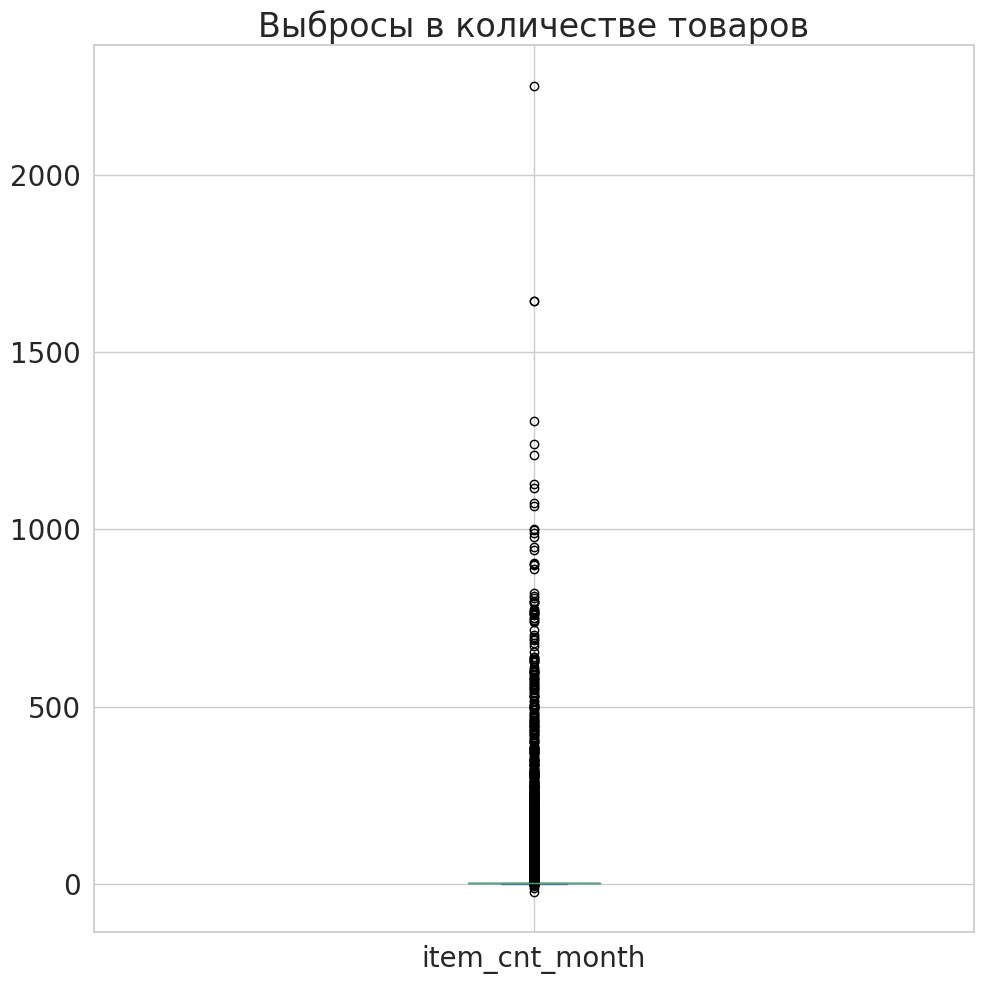

In [132]:
# Построение боксплота
ax = train_grouped["item_cnt_month"].plot(kind="box", subplots=True, figsize=(10, 10), fontsize=20)
plt.title("Выбросы в количестве товаров", fontsize=24, x=0.5)

# Настройка макета
plt.tight_layout()

In [133]:
def get_bounds(data, column):
    q25 = data[column].quantile(0.25) # Рассчёт интерквартильного размаха
    q75 = data[column].quantile(0.75)
    iqr = q75 - q25
    bound = (q25 - iqr * 1.5, q75 + iqr * 1.5)
    out_of_bound = ( data[column] > bound[1]) | ( data[column] < bound[0])
    anom_count = data[column][ out_of_bound ].count()

    print("\033[1m",column,"\033[0m")
    print("Интерквартильный размах", bound)
    print(f"Диапазон значений: ({data[column].min()}; {data[column].max()})")
    print("Количество выбросов: ", anom_count)
    print("Их процент в выборке: ", anom_count / len(data) * 100, '\n')

    return [bound[0], bound[1], out_of_bound]

In [134]:
outliars = get_bounds(train_grouped, "item_cnt_month")

 item_cnt_month 
Интерквартильный размах (np.float64(-0.5), np.float64(3.5))
Диапазон значений: (-22; 2253)
Количество выбросов:  178986
Их процент в выборке:  11.12320189320518 



Так как в интерквартильный размах входят только количество 1 шт, ограничим значения в ручную верхней границей в 600 шт. Ниже этой отметки плотность точек заметно увеличивается. Также ограничим признак снизу значением 0, чтобы не учитывать возвраты товаров в прогнозировании продаж.

In [135]:
# Ограничим значения целевого признака
train_grouped['item_cnt_month'] = train_grouped['item_cnt_month'].clip(0,600)

In [136]:
from itertools import product # для декартового произведения

def create_full_train(data):
    # Генерация полной матрицы shop_id × item_id × date_block_num (=year+month)
    grid = []

    for block_num in data['date_block_num'].unique():
      unique_shops = data.loc[data['date_block_num'] == block_num, 'shop_id'].unique()
      unique_items = data.loc[data['date_block_num'] == block_num, 'item_id'].unique()
      grid.append(np.array(list(product([block_num], unique_shops, unique_items)), dtype='int32'))

    grid = pd.DataFrame(np.vstack(grid), columns=['date_block_num', 'shop_id', 'item_id'])

    final_grid = pd.merge(grid, train_grouped, on=['date_block_num', 'shop_id', 'item_id'], how='left')

    final_grid['item_cnt_month'] = final_grid['item_cnt_month'].fillna(0).astype(np.int32)

    final_grid['item_cnt_month'] = final_grid['item_cnt_month'].clip(0,500)
    return final_grid

In [137]:
train = create_full_train(train)

In [138]:
# Добавление месяца и года
train['month'] = (train['date_block_num'] % 12) + 1
train['year'] = (train['date_block_num'] // 12) + 2013

In [139]:
descr_features(train)

,data_type,meaning,n_NaN,%NaN,nunique,count,mean,std,min,25%,50%,75%,max
date_block_num,int32,"Порядковый номер месяца, используемый для удоб...",0,0.0,34,10913804.0,15.0,10.0,0.0,7.0,14.0,23.0,33.0
item_cnt_month,int32,new,0,0.0,357,10913804.0,0.0,3.0,0.0,0.0,0.0,0.0,500.0
month,int64,new,0,0.0,12,10913804.0,6.0,3.0,1.0,3.0,6.0,9.0,12.0
year,int64,new,0,0.0,3,10913804.0,2014.0,1.0,2013.0,2013.0,2014.0,2014.0,2015.0


## Визуальный анализ

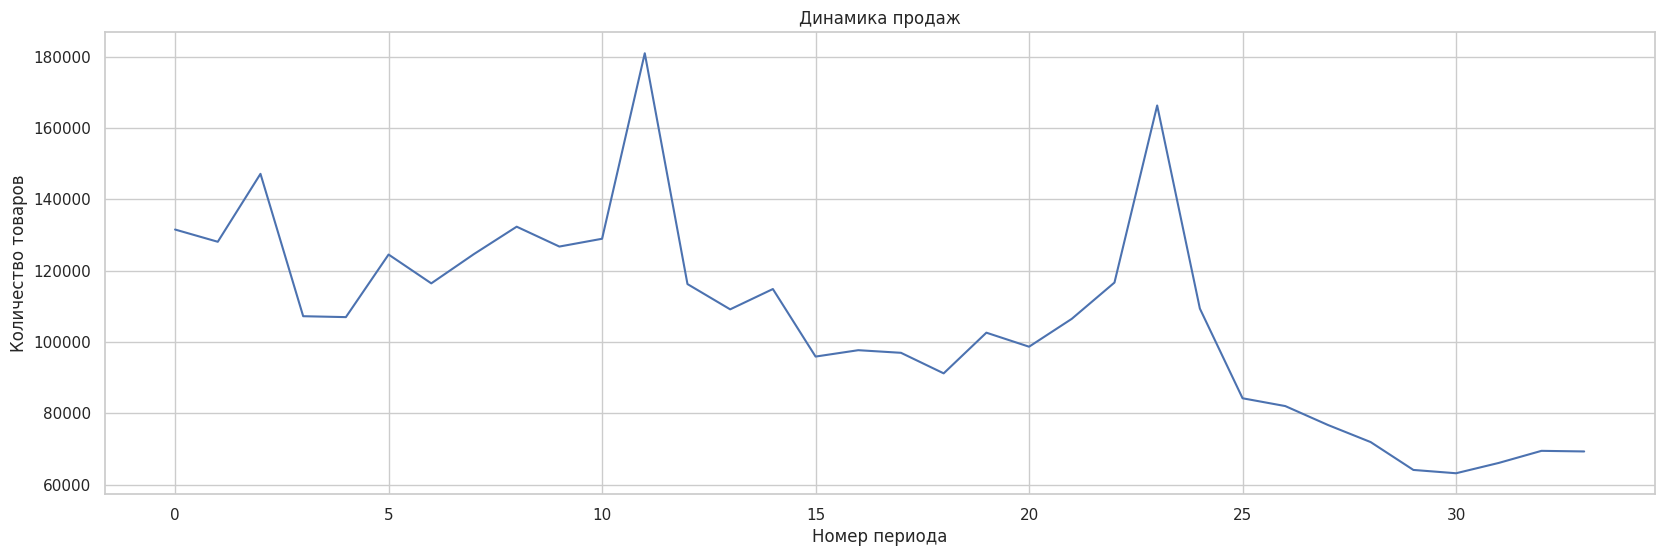

In [140]:
# Построение линейного графика продаж
monthly_total_sales = train.groupby('date_block_num')['item_cnt_month'].sum()

plt.figure(figsize=(20,6))
plt.plot(monthly_total_sales.index, monthly_total_sales.values)
plt.xlabel('Номер периода')
plt.ylabel('Количество товаров')
plt.title('Динамика продаж')
plt.grid(True)
plt.show()

In [141]:
train["year"].value_counts()

,count
year,
2013,4488710
2014,3939517
2015,2485577


Виден убывающий тренд, однако данных за каждый последующий год меньше, поэтому нельзя утверждать, что продажи падают.

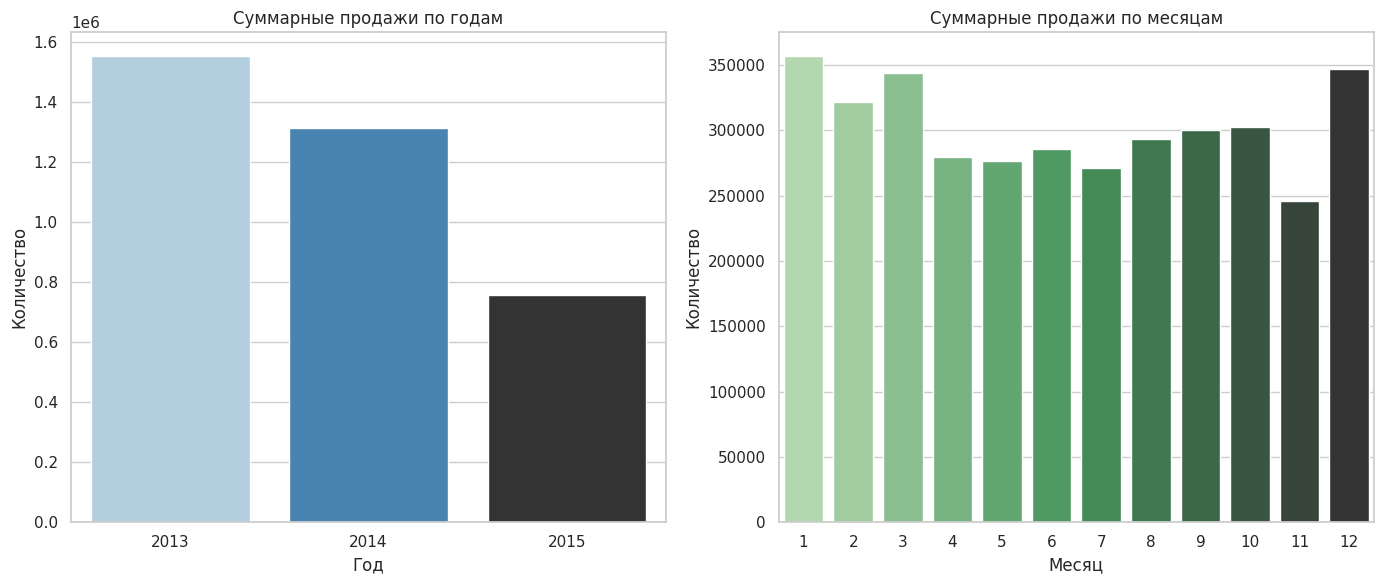

In [142]:
# Настройки стиля
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Диаграмма по годам
plt.subplot(1, 2, 1)
revenue_by_year = train.groupby('year', as_index=False)['item_cnt_month'].sum()
sns.barplot(data=revenue_by_year, x='year', y='item_cnt_month', hue='year', palette="Blues_d", legend=False)
plt.title("Суммарные продажи по годам")
plt.xlabel("Год")
plt.ylabel("Количество")

# Диаграмма по месяцам
plt.subplot(1, 2, 2)
revenue_by_month = train.groupby('month', as_index=False)['item_cnt_month'].sum()
sns.barplot(data=revenue_by_month, x='month', y='item_cnt_month', hue='month', palette="Greens_d", legend=False)
plt.title("Суммарные продажи по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество")

plt.tight_layout()

В зимние месяцы наблюдается увеличение продаж. Может быть связано с сезонностью наших товаров.

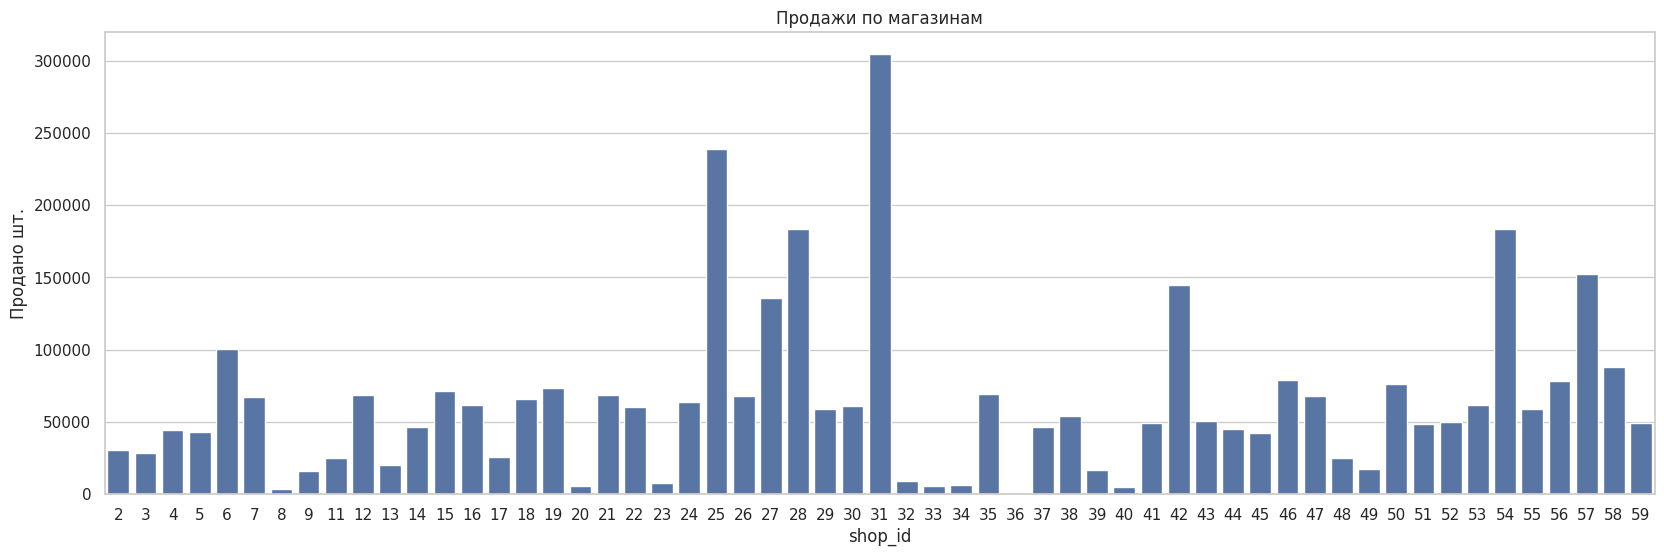

In [143]:
# Продажи по магазинам
plt.figure(figsize=(20, 6))
shop_sales = train.groupby('shop_id')['item_cnt_month'].sum().sort_values(ascending=False)
sns.barplot(x=shop_sales.index, y=shop_sales.values)
plt.title('Продажи по магазинам')
plt.xlabel('shop_id')
plt.ylabel('Продано шт.')
plt.show()

Магазин 31 отличается большими продажами

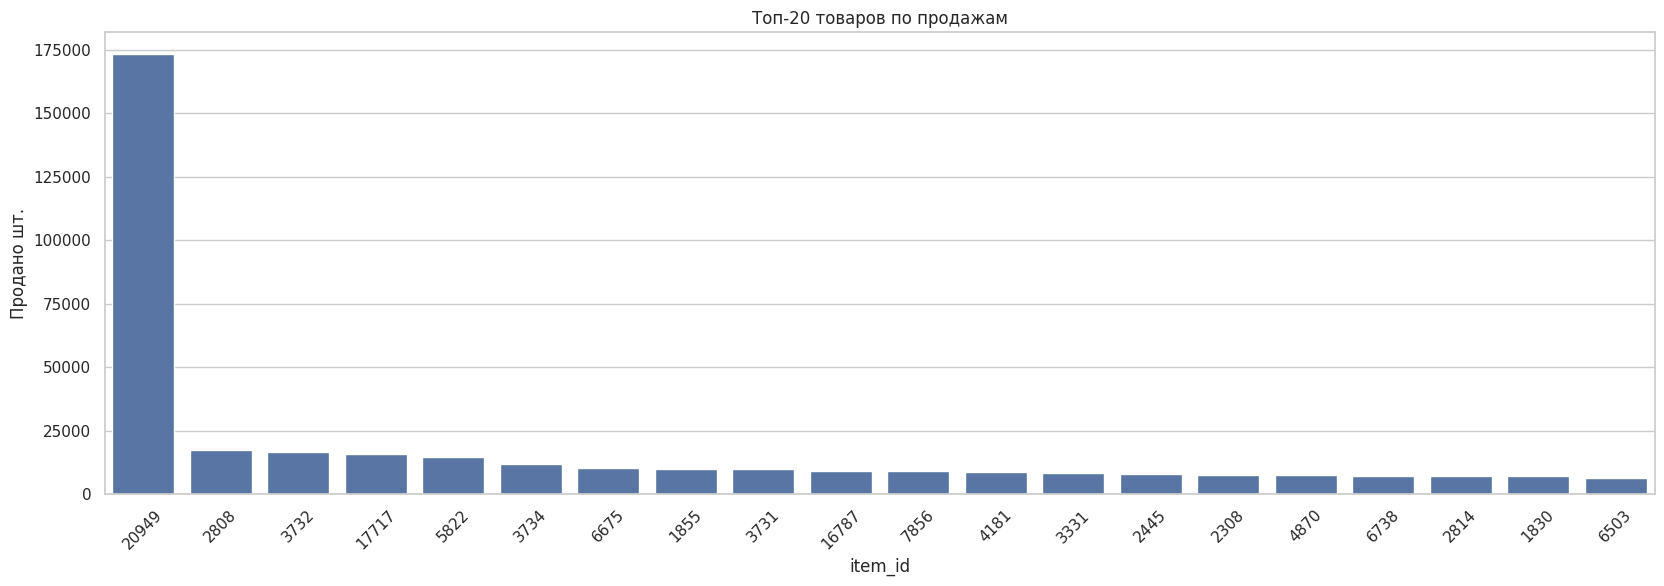

In [144]:
# Продажи по товарам (топ-20)
plt.figure(figsize=(20, 6))
top_items = train.groupby('item_id')['item_cnt_month'].sum().sort_values(ascending=False).head(20)
sns.barplot(x=top_items.index.astype(str), y=top_items.values)
plt.title('Топ-20 товаров по продажам')
plt.xlabel('item_id')
plt.ylabel('Продано шт.')
plt.xticks(rotation=45)

plt.show()

У нас есть очень популярный товар 209949

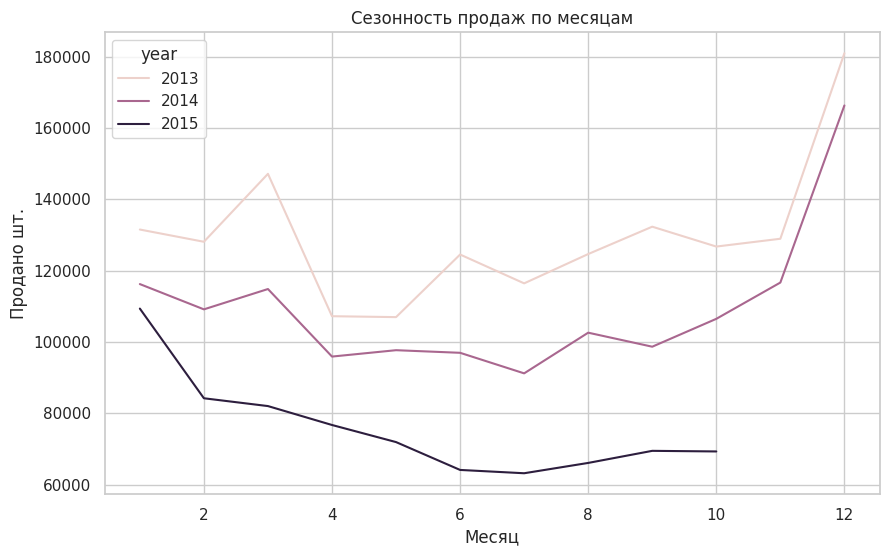

In [145]:
# Продажи по месяцам в разрезе лет
plt.figure(figsize=(10, 6))
seasonal = train.groupby(['year', 'month'])['item_cnt_month'].sum().reset_index()
seasonal['year_month'] = seasonal['year'].astype(str) + '-' + seasonal['month'].astype(str)
sns.lineplot(data=seasonal, x='month', y='item_cnt_month', hue='year')
plt.title('Сезонность продаж по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Продано шт.')

plt.show()

Наблюдается подъём продаж в зимнем периоде, как было показано ранее

## Сохранение датафрейма

In [146]:
train.to_csv("/content/drive/MyDrive/DS/data/full_train.csv")
test.to_csv("/content/drive/MyDrive/DS/data/test.csv")